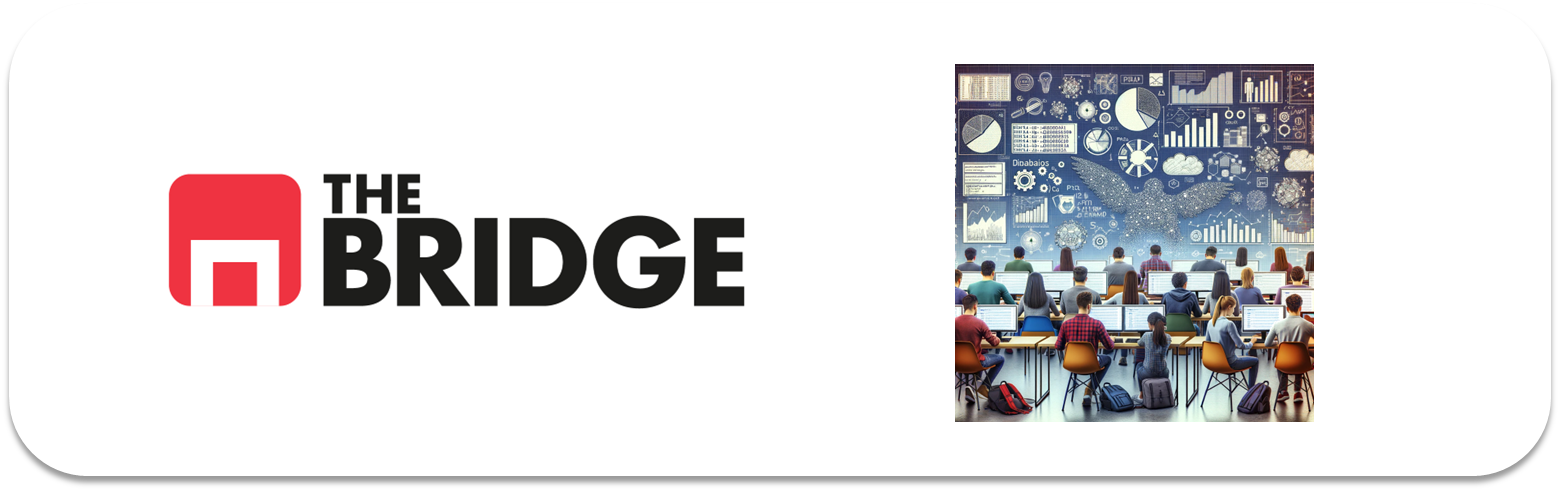

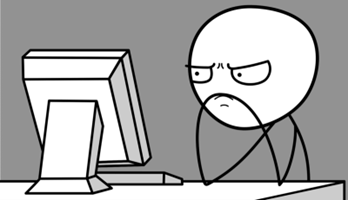

Para ejercitarte y afianzar lo aprendido sobre **Proceso de Datos**, como primera etapa de ML, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

### Ejercicio 1

Carga el dataset de advertising que encontrarás en la carpeta de datos. Muestra su información general. ¿Qué te llama la atención? ¿Tendremos que limpiar alguna variable?

In [2]:
df_ad = pd.read_csv("./data/advertising_ml.csv")

In [13]:
df_ad.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [19]:
df_ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Daily Time Spent on Site  1000 non-null   float64       
 1   Age                       1000 non-null   int64         
 2   Area Income               1000 non-null   float64       
 3   Daily Internet Usage      1000 non-null   float64       
 4   Ad Topic Line             1000 non-null   object        
 5   City                      1000 non-null   object        
 6   Male                      1000 non-null   int64         
 7   Country                   1000 non-null   object        
 8   Timestamp                 1000 non-null   datetime64[ns]
 9   Clicked on Ad             1000 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 78.3+ KB


In [7]:
df_ad.describe()


,Daily Time Spent on Site,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,55000.000080,180.000100,0.481000,0.50000
std,15.853615,13414.634022,43.902339,0.499889,0.50025
min,32.600000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,65470.635000,218.792500,1.000000,1.00000
max,91.430000,79484.800000,269.960000,1.000000,1.00000


In [9]:
df_ad["Ad Topic Line"].nunique()

1000

In [12]:
df_ad["Age"] = df_ad["Age"].str.extract(r"(\d+)").astype(int)

In [18]:
df_ad["Timestamp"] = pd.to_datetime(df_ad["Timestamp"])

In [25]:
cardinalidad = df_ad["Country"].nunique() / len(df_ad)
cardinalidad1 = df_ad["City"].nunique() / len(df_ad)
cardinalidad2 = df_ad["Ad Topic Line"].nunique() / len(df_ad)
cardinalidad, cardinalidad1, cardinalidad2

(0.237, 0.969, 1.0)

La columna Age requiere limpieza, eliminando el texto y convirtiéndola a un tipo numérico. La variable Ad Topic Line presenta una cardinalidad muy elevada, lo que dificulta su codificación y generalización, por lo que no resulta adecuada para su uso directo en el modelo. Por último, la columna Timestamp debería transformarse a un tipo datetime para poder ser tratada correctamente.

### Ejercicio 2

Tenemos que entender el problema antes de seguir. Nos dicen que la compañía "QuickRespond" quiere poder generar un modelo que a partir de datos como los del dataset para poder dirigir mejor su campaña de anuncios. Hablando con ellos llegamos a la conclusión de que queremos un modelo para poder predecir si un usuario pulsará en el link de un anuncio o no. ¿Qué tipo de problemas estamos tratando?¿Y de que tipo de aprendizaje?¿Existe una variable target que puedas identificar rapidamente?

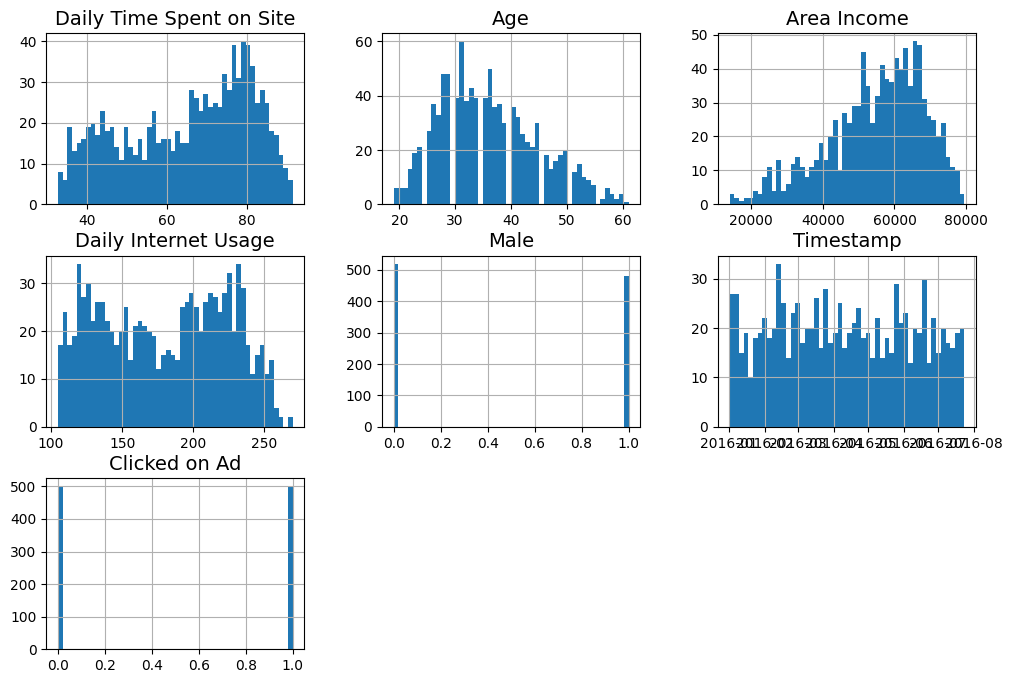

In [27]:
# Código extra para los tamaños de las fuentes y los "ticks" de los ejes, esto no lo vimos al hablar de matplotlib así que una extra
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df_ad.hist(bins=50, figsize=(12, 8)) # La forma de generar histogramas de una sola vez para las variables numéricas de un dataset
plt.show()

El tipo de problema es de clasificación, ya que tenmos que predecir si un usuario pulsará o no el llink.
El aprendizaje será supervisado ya que en el dataset tenemos ejemplos de usuarios que han pulsado y otros que no.
Variable target clicked on ad ya que es el fin que queremos obtener en la predicción

### Ejercicio 3

Volvamos ya a los datos. Intenta dar una definicón de cada columna, obten su cardinalidad y en función de esta y del tipo de variable de pandas, clasifícalas en categóricas y numéricas.

In [28]:
df_ad.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


Daily Time Spent on Site Tiempo que deduzco que es en minutos que el usuario ha estado en la web  
Age	Edad del usuario  
Area Income	El salario medio de la zona del usuario  
Daily Internet Usage Uso medio en minutos, deduzco, del usuario en internet   
Ad Topic Line anuncio presentado al usuario  
City Ciudad del usuario  
Male Si es hombre o no  
Country	País del usuario  
Timestamp Deduzco que es el momento en el que apareció el anuncio  
Clicked on Ad Si el usuario clico o no en el anuncio  

In [32]:
def cardinalidad(df_col):
    
    return df_ad[df_col].nunique() / len(df_ad)


lst_col = df_ad.columns

for col in lst_col:
    print(f"Cardinalidad de {col} = {cardinalidad(col)}")
    
df_ad.info()

Cardinalidad de Daily Time Spent on Site = 0.9
Cardinalidad de Age = 0.043
Cardinalidad de Area Income = 1.0
Cardinalidad de Daily Internet Usage = 0.966
Cardinalidad de Ad Topic Line = 1.0
Cardinalidad de City = 0.969
Cardinalidad de Male = 0.002
Cardinalidad de Country = 0.237
Cardinalidad de Timestamp = 1.0
Cardinalidad de Clicked on Ad = 0.002
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Daily Time Spent on Site  1000 non-null   float64       
 1   Age                       1000 non-null   int64         
 2   Area Income               1000 non-null   float64       
 3   Daily Internet Usage      1000 non-null   float64       
 4   Ad Topic Line             1000 non-null   object        
 5   City                      1000 non-null   object        
 6   Male                      1000 non-null   i

Basandome en la cardinalidad y tipo de dato por columna defino que:    
 0   Daily Time Spent on Site  1000 non-null   float64  Numerica continua          
 1   Age                       1000 non-null   int64    Numerica continua       
 2   Area Income               1000 non-null   float64  Numerica continua       
 3   Daily Internet Usage      1000 non-null   float64  Numerica continua  
 4   Ad Topic Line             1000 non-null   object   Categorica con alta cardinalidad      
 5   City                      1000 non-null   object   Categorica con alta cardinalidad       
 6   Male                      1000 non-null   int64    Categorica binaria       
 7   Country                   1000 non-null   object   Categorica media cardinalidad       
 8   Timestamp                 1000 non-null   datetime64[ns]  Variable temporal      
 9   Clicked on Ad             1000 non-null   int64   Categorica binaria     

### Ejercicio 4

Limpia las columnas que necesiten ser limpiadas, no completes nulos (porque asignar valores a nulos sólo puedes hacerlo primero con el train, ya explicaremos con detalle por qué). 

### Ejercicio 5

Divide el datset en train y test, empleando sklearn para ello tal y como hemos hecho en el workout. Usa la regla del 80-20

In [34]:
train_set, test_set = train_test_split(df_ad, test_size=0.2, random_state=42)

### Ejercicio 6

Haz un pequeño análisis univariante de las columnas numéricas (muestra sus histogramas)

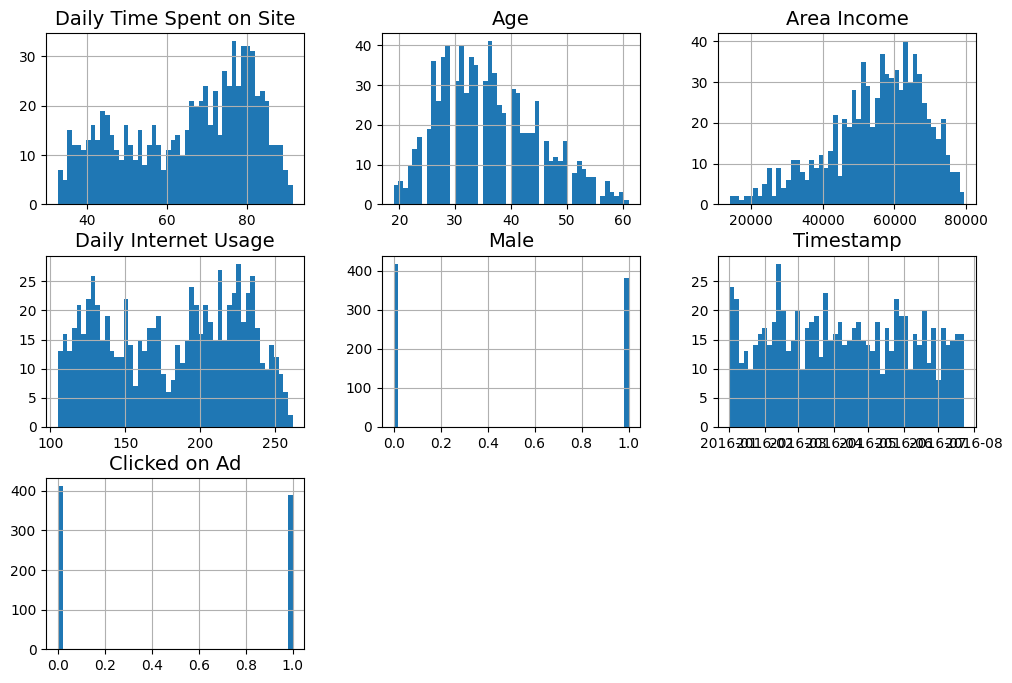

In [35]:
train_set.hist(bins=50, figsize=(12, 8)) # La forma de generar histogramas de una sola vez para las variables numéricas de un dataset
plt.show()

Daily Time Spent on Site -> mayor densidad en valores altos    
Age -> Distribución aproximadamente normal, con mayor concentración en valores intermedios y ligera asimetría.
Area Income -> la mayoría de observaciones se concentran entre 50.000/70.000   
Daily Internet Usage -> no se observa un patrón claro   
Male -> Distribución equilibrada   
Timestamp -> No obtengo conclusiones claras    
Clicked on Ad -> no puedo sacar conclusiones mas de que es un distribució equilibrada

### Ejercicio 7

Muestra las correlaciones de las variables continuas con un "PairPlot" y emplea como codigo de color la variable target. [Esto es otra forma de hacer un bivariante y un multivariante a la vez]. Para ello como argumento del pairplot de seaborn usa el dataframe de train (no la matriz de correlación)

In [36]:
corr_matrix = train_set.corr(numeric_only= True)
corr_matrix["Clicked on Ad"].sort_values(ascending = False)

Clicked on Ad               1.000000
Age                         0.482848
Male                       -0.043798
Area Income                -0.498504
Daily Time Spent on Site   -0.745492
Daily Internet Usage       -0.812130
Name: Clicked on Ad, dtype: float64

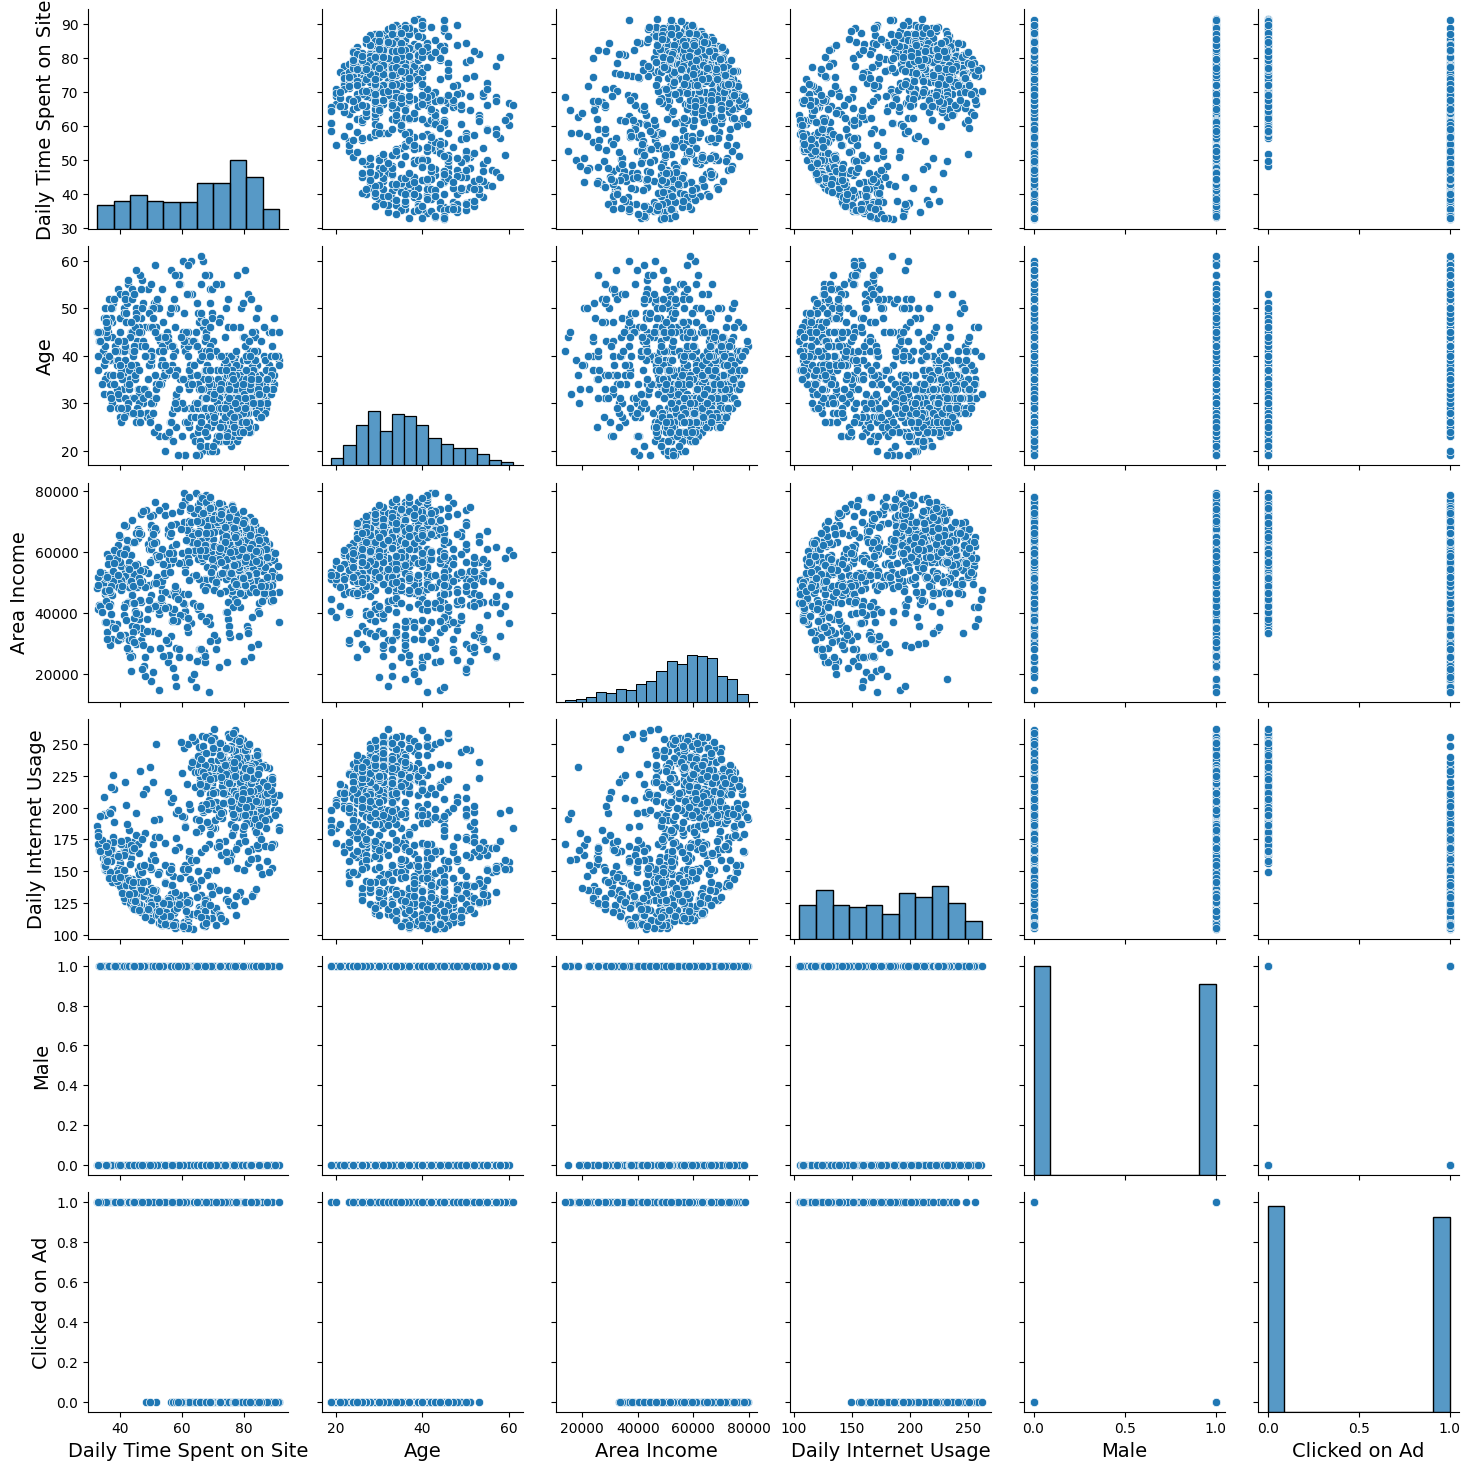

In [38]:
sns.pairplot(train_set[corr_matrix.columns]);

### Ejercicio 8

Fijándote en la diagonal principal del gráfico anterior haz una selecció de features:

Se seleccionan como features Age, Area Income, Daily Time Spent on Site y Daily Internet Usage, ya que presentan correlaciones moderadas o fuertes con la variable target.

Se descarta Male debido a su correlación prácticamente nula con el click. Las variables categóricas y la variable temporal Timestamp se descartan en esta fase, ya que no aportan señal directa o requerirían un preprocesado adicional fuera del alcance del ejercicio.